### langgraph(Graph API)

compnents of langgraph
- edges
- Nodes
- state

In [1]:
from typing import Annotated 
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]


graph = StateGraph(State)


In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq

llm = ChatGroq(model = "qwen/qwen3.6-27b")

In [5]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.17'}}, client=<groq.resources.chat.completions.Completions object at 0x0000020F42B24EC0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000020F42B25940>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [6]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [7]:
graph_builder = StateGraph(State)

graph_builder.add_node("llmchatbot",chatbot)
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

graph = graph_builder.compile()

In [8]:
response =graph.invoke({"messages": "Hi"})

In [9]:
response["messages"][-1].content

'\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:** The user said "Hi". This is a simple greeting.\n2.  **Identify Intent:** The user is initiating a conversation. No specific question or task is provided.\n3.  **Determine Response Strategy:** \n   - Acknowledge the greeting warmly\n   - Keep it open-ended to encourage further interaction\n   - Offer assistance\n   - Maintain a friendly, professional tone\n4.  **Draft Response (Mental):** "Hello! How can I help you today?" or "Hi there! What\'s on your mind?" or "Hey! How can I assist you?"\n5.  **Refine Response:** Keep it concise and inviting. "Hello! How can I help you today?" works well. It\'s polite, clear, and prompts the user to share their needs.\n6.  **Final Output Generation:** Match the refined response.✅\n</think>\n\nHello! How can I help you today? 😊'

In [10]:
import re

for event in graph.stream({"messages": "Hi,How are you?"}):
    for values in event.values():
        content = values["messages"][-1].content

        # Remove the <think>...</think> block if it exists
        clean_content = re.sub(r'<think>.*?</think>', '', content, flags=re.DOTALL).strip()

        # Only print if there is remaining text to display
        if clean_content:
            print(clean_content)

Hi! I'm doing well, thank you for asking. How are you doing? Is there anything I can help you with today? 😊


In [11]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=3, api_key=os.environ.get("TAVILY_API_KEY"))
tool.invoke("what happened in bangalore today?")

{'query': 'what happened in bangalore today?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://indianexpress.com/section/cities/bangalore',
   'title': 'Bangalore News: Latest Bengaluru News, Karnataka Bangalore News Today and Headlines | The Indian Express',
   'content': 'Bengaluru medical shop owner murder, Bengaluru medical shop owner Madiwala, Bengaluru murder, Madiwala Main Road murder, Bengaluru crime news, revenge murder Bengaluru, gang rivalry Bengaluru, Bandepalya gang rivalry, Bengaluru police, Indian Express news, Bengaluru crime news, Bengaluru police news\n\n## Medical shop owner hacked to death with machetes on busy Bengaluru road [...] ### Bengaluru police seize Rs 9 crore unaccounted cash from Kerala car\n\nfake ICU drugs\n\n### Fake ICU drugs seizure: Karnataka sets up 6-member SIT to probe statewide racket\n\nKarnataka Home Minister Priyank Kharge said the verification was carried out as part of an exercise to identify and 

In [12]:
def multiply(a: int, b: int) -> int:
    """
    Multiplies two integers and returns the result.
    args:
        a (int): The first integer.
        b (int): The second integer.
    Returns:
        int: The product of the two integers.
    """
    return a * b

In [13]:
tools= [tool,multiply]

In [14]:
llm_with_tool=llm.bind_tools(tools)

In [15]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.17'}}, client=<groq.resources.chat.completions.Completions object at 0x0000020F42B24EC0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000020F42B25940>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look up', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'str

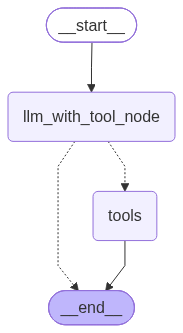

In [30]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

##node definition
def llm_with_tool_node(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


builder = StateGraph(State)
builder.add_node("llm_with_tool_node",llm_with_tool_node)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"llm_with_tool_node")
builder.add_conditional_edges("llm_with_tool_node",tools_condition)
builder.add_edge("tools",END)
##builder.add_edge("tools","llm_with_tool_node")
##builder.add_edge("llm_with_tool_node",END)

graph = builder.compile()

from IPython.display import Image, display, HTML
display(Image(graph.get_graph().draw_mermaid_png()))


In [31]:
response = graph.invoke({"messages": "what happened in bangalore today?"})

In [33]:
response["messages"]

[HumanMessage(content='what happened in bangalore today?', additional_kwargs={}, response_metadata={}, id='85890f96-08d9-4c56-9b1e-a06f9e74a1ac'),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'The user is asking for news about Bangalore happening "today".\nI need to use a search tool to find recent news or events in Bangalore.\nThe `tavily_search` tool is suitable for this.\nI will set the `query` to "news in Bangalore today".\nI will set the `time_range` to "day" to ensure I get information for today.\nI will set the `topic` to "news" to prioritize news articles.\nThe `start_date` and `end_date` are not strictly necessary if I use `time_range`, but `time_range` is sufficient.\nI will call `tavily_search`.\n', 'tool_calls': [{'id': 'pmhn4b80y', 'function': {'arguments': '{"query":"news in Bangalore today","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 191, 'prompt_tokens': 1